# Imports

In [1]:
import os
import sys

In [2]:
current_dir =  os.getcwd()
# replace this following line in the path your frank2d files are.
parent_dir = os.path.abspath(os.path.join(current_dir, os.pardir))
sys.path.append(parent_dir)

In [3]:
parent_dir

'/localhome/home/zgdz996/frank2d'

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import time

In [5]:
machine = 'cpu'  # 'cpu' or 'gpu'
if machine == 'gpu':
    #frank2d
    from frank2d_gpu.frank2d_gpu import Frank2D
    from frank2d_gpu.geometry import Geometry
    from frank2d_gpu.fourier2d_gpu import FourierTransform2D
    from frank2d_gpu.process_vis_gpu import Gridding
    from frank2d_gpu.plot_gpu import Plot
    from frank2d_gpu.constants import rad_to_arcsec, deg_to_rad
    from frank2d_gpu.posterior_optimization_gpu import MAPEstimator

elif machine == 'cpu':
    # frank2d
    from frank2d import Frank2D
    from frank2d.geometry import Geometry
    from frank2d.posterior_optimization import *
    from frank2d.constants import rad_to_arcsec, deg_to_rad
    from frank2d.plot import Plot


In [6]:
disc = 'AS209'

In [7]:
dir = "./../../data/"
if disc == 'Simulated':
    data_file = dir + "uvtable_nonsym_disc_blob_noisy.npz"
    inc = 0
    pa = 0
    dra = 0
    ddec = 0
    rout = 1*2

    file = np.load(data_file)
    u, v, Vis, Weights = file['u'], file['v'], file['vis'], file['weights']

if disc == 'AS209':
    AS209 = {'inc': 34.97, 'pa': 85.76, 'dra':1.9e-3, 'ddec':-2.5e-3, 'rout': 1.2*2, 'disk_name': 'AS209'}
    data_file = dir +"uvtable_" + disc + "_continuum.npz"

    inc = AS209['inc']
    pa = AS209['pa']
    dra = AS209['dra']
    ddec = AS209['ddec']
    rout = AS209['rout']

    file = np.load(data_file)
    u, v, Re, Im, Weights = file['u'], file['v'], file['Re'], file['Im'], file['w']
    Vis = Re + Im*1j


if disc =='Elias27':
    Elias27 = {'inc': 56.2, 'pa': 118.8, 'dra':-5e-3, 'ddec':-8e-3, 'rout': 1.88*2, 'disk_name': 'Elias27'}
    data_file = dir +"uvtable_" + disc + "_continuum.npz"
    inc = Elias27['inc']
    pa = Elias27['pa']
    dra = Elias27['dra']
    ddec = Elias27['ddec']
    rout = Elias27['rout']

    file = np.load(data_file)
    u, v, Re, Im, Weights = file['u'], file['v'], file['Re'], file['Im'], file['w']
    Vis = Re + Im*1j

uvtable = {'u': u, 'v': v, 'vis': Vis, 'weights': Weights }
geom = Geometry(inc, pa, dra, ddec)

## Frank2d params

In [8]:
N = 300

In [9]:
frank2d = Frank2D(N, rout)
frank2d.process_vis(uvtable)


===>  Setting gridded data...


In [10]:
initial_guess = {'m': -2, 'logl': 4}
frank2d.search_MAP(initial_guess= initial_guess, N = 50)


Using existing visibility data...
!!!!!!!!! 1519283.783515117
Fitting the visibilities with Frank2D with 2DFT...


 + Time to preprocess the visibilities: 70.40 seconds
Setting the initial guess...
Optimizing the posterior...


In [11]:
MAPEs = frank2d.MAPEstimator
GP =  MAPEs.GaussianModel

In [24]:
ps = [-3, -2, -1, 0, 1]
ms = np.linspace(-2, -5, 100)
logl = 4

In [25]:
minus_log_likelihood_array = []
intensity_array = []
logdetS_array = []
logdetD_array = []
jTDj_array = []

In [26]:
for p in ps:
    print(f"============================ p: {p} ============================")
    minus_log_likelihood_array.append([])
    intensity_array.append([])
    logdetS_array.append([])
    logdetD_array.append([])
    jTDj_array.append([])
    for m in ms:
        print(f"    ---------------------------- m: {m}")
        c = p - 5*m
        params = {'m': m, 'logc': np.log10(c),  'logl': logl}
        minus_log_likelihood = GP.minus_log_posterior(params)
        logdetS, logdetD, jTDj = GP.logdetS, GP.logdetD, GP.jDj
        minus_log_likelihood_array[-1].append(minus_log_likelihood)
        logdetS_array[-1].append(logdetS)
        logdetD_array[-1].append(logdetD)
        jTDj_array[-1].append(jTDj)
        intensity_array[-1].append(GP.sol)
        print(f"            -> (m, log_c):({m}, {c}) with likelihood: {minus_log_likelihood: 2e}")

    dict_p = {
        'p': p,
        'ms': ms,
        'minus_log_likelihood': minus_log_likelihood_array,
        'intensity': intensity_array,
        'logdetS': logdetS_array,
        'logdetD': logdetD_array,
        'jTDj': jTDj_array
    }

    import pickle
    path =  dir + disc + f'_frank2d_varyingm_with_p{p}.pkl'
    with open(path, 'wb') as f:
        pickle.dump(dict_p, f)

============================ p: -3 ============================
    ---------------------------- m: -2.0


            -> (m, log_c):(-2.0, 7.0) with likelihood: -4.077974e+07
    ---------------------------- m: -2.0303030303030303
            -> (m, log_c):(-2.0303030303030303, 7.151515151515152) with likelihood: -3.450311e+07
    ---------------------------- m: -2.0606060606060606
            -> (m, log_c):(-2.0606060606060606, 7.303030303030303) with likelihood: -2.868908e+07
    ---------------------------- m: -2.090909090909091
            -> (m, log_c):(-2.090909090909091, 7.454545454545453) with likelihood: -2.343951e+07
    ---------------------------- m: -2.121212121212121
            -> (m, log_c):(-2.121212121212121, 7.6060606060606055) with likelihood: -1.882660e+07
    ---------------------------- m: -2.1515151515151514
            -> (m, log_c):(-2.1515151515151514, 7.757575757575758) with likelihood: -1.488259e+07
    ---------------------------- m: -2.1818181818181817
            -> (m, log_c):(-2.1818181818181817, 7.909090909090908) with likelihood: -1.159768e+07
    ------

In [27]:
p_m3_minus_log_likelihood = minus_log_likelihood_array[0]
p_m2_minus_log_likelihood = minus_log_likelihood_array[1]
p_m1_minus_log_likelihood = minus_log_likelihood_array[2]
p_m0_minus_log_likelihood = minus_log_likelihood_array[3]
p_p1_minus_log_likelihood = minus_log_likelihood_array[4]

p_m3_intensity = intensity_array[0]
p_m2_intensity = intensity_array[1]
p_m1_intensity = intensity_array[2]
p_m0_intensity = intensity_array[3]
p_p1_intensity = intensity_array[4]

p_m3_logdetS = logdetS_array[0]
p_m2_logdetS = logdetS_array[1]
p_m1_logdetS = logdetS_array[2]
p_m0_logdetS = logdetS_array[3]
p_p1_logdetS = logdetS_array[4]

p_m3_logdetD = logdetD_array[0]
p_m2_logdetD = logdetD_array[1]
p_m1_logdetD = logdetD_array[2]
p_m0_logdetD = logdetD_array[3]
p_p1_logdetD = logdetD_array[4]

p_m3_jTDj = jTDj_array[0]
p_m2_jTDj = jTDj_array[1]
p_m1_jTDj = jTDj_array[2]
p_m0_jTDj = jTDj_array[3]
p_p1_jTDj = jTDj_array[4]



In [28]:
p_m3_minus_log_likelihood

[-40779737.48322298,
 -34503105.302166894,
 -28689084.36983369,
 -23439511.434048392,
 -18826597.552459046,
 -14882588.302811045,
 -11597682.574330656,
 -8926366.755902851,
 -6799013.045658542,
 -5134547.730875667,
 -3851022.2918245094,
 -2872718.338405761,
 -2133874.987346487,
 -1579856.4818759118,
 -1166714.1583553192,
 -859927.013649981,
 -632852.0888988408,
 -465193.094296804,
 -341637.7327852372,
 -250716.94866784135,
 -183886.51366849206,
 -134806.8037400348,
 -98788.23240397299,
 -72369.74887257112,
 -53001.458207640695,
 -38807.26773358165,
 -28408.269897171387,
 -20791.807785346627,
 -15214.676831302444,
 -11131.712765420236,
 -8143.191903877927,
 -5956.135377132579,
 -4355.869096559181,
 -3185.13701891326,
 -2328.7708757870473,
 -1702.4437034397827,
 -1244.4226522340555,
 -909.5232886590318,
 -664.6790403227078,
 -485.69513388072943,
 -354.8709081532318,
 -259.2585643222725,
 -189.3882441622647,
 -138.33471560050572,
 -101.03424913161064,
 -73.78469678404025,
 -53.87969713503

Text(0.5, 1.0, 'p($10^5$) = -3')

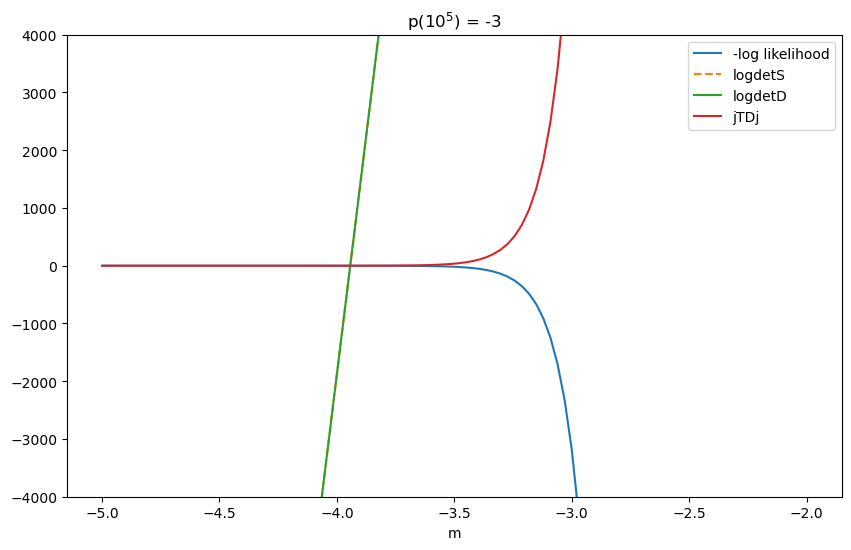

In [29]:
# plot all values against ms for each p

plt.figure(figsize=(10, 6))
plt.plot(ms, p_m3_minus_log_likelihood, label='-log likelihood')
#plt.plot(ms, p_m3_intensity, label = 'intensity')
plt.plot(ms, p_m3_logdetS, ls = '--', label='logdetS')
plt.plot(ms, p_m3_logdetD, label='logdetD')
plt.plot(ms, p_m3_jTDj, label='jTDj')
#plt.yscale('log')
plt.legend()
plt.ylim(-4000, 4000)
plt.xlabel('m')
plt.title(r'p($10^5$) = -3')


Text(0.5, 1.0, 'p($10^5$) = -2')

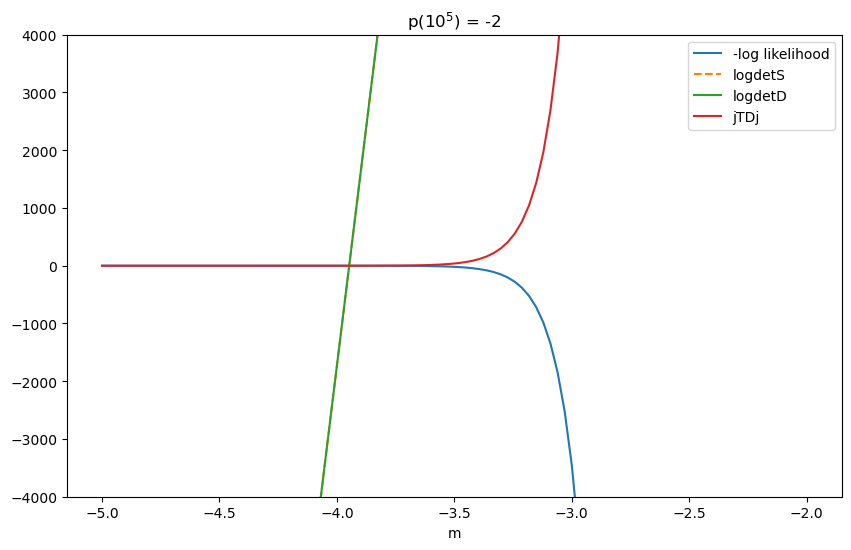

In [30]:
plt.figure(figsize=(10, 6))
plt.plot(ms, p_m2_minus_log_likelihood, label='-log likelihood')
#plt.plot(ms, p_m2_intensity, label = 'intensity')
plt.plot(ms, p_m2_logdetS, ls = '--', label='logdetS')
plt.plot(ms, p_m2_logdetD, label='logdetD')
plt.plot(ms, p_m2_jTDj, label='jTDj')
#plt.yscale('log')
plt.ylim(-4000, 4000)
plt.legend()
plt.xlabel('m')
plt.title(r'p($10^5$) = -2')


Text(0.5, 1.0, 'p($10^5$) = -1')

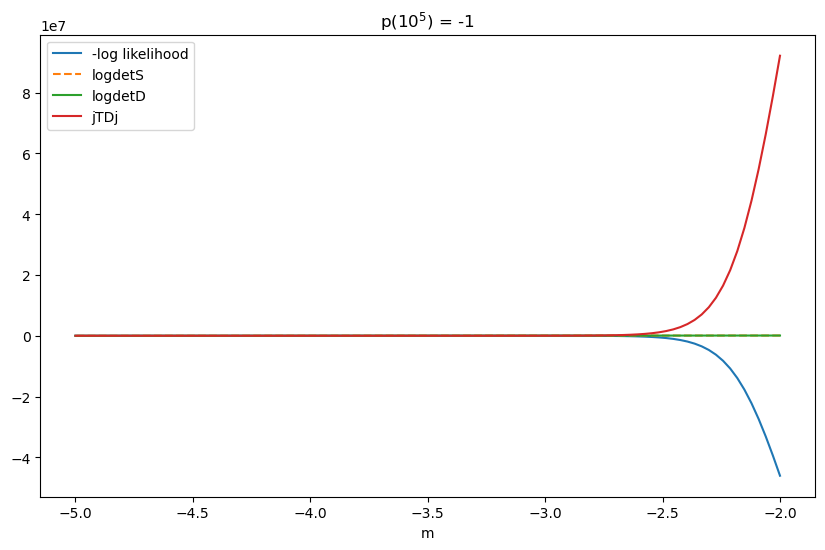

In [31]:
plt.figure(figsize=(10, 6))
plt.plot(ms, p_m1_minus_log_likelihood, label='-log likelihood')
#plt.plot(ms, p_m1_intensity, label = 'intensity')
plt.plot(ms, p_m1_logdetS, ls = '--', label='logdetS')
plt.plot(ms, p_m1_logdetD, label='logdetD')
plt.plot(ms, p_m1_jTDj, label='jTDj')
#plt.yscale('log')
plt.legend()
plt.xlabel('m')
plt.title(r'p($10^5$) = -1')


Text(0.5, 1.0, 'p($10^5$) = 0')

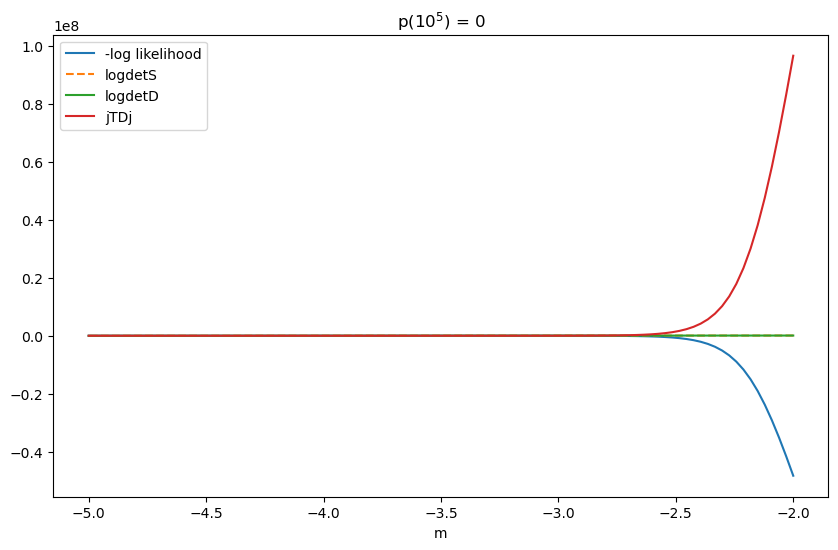

In [32]:
plt.figure(figsize=(10, 6))
plt.plot(ms, p_m0_minus_log_likelihood, label='-log likelihood')
#plt.plot(ms, p_m0_intensity, label = 'intensity')
plt.plot(ms, p_m0_logdetS, ls = '--', label='logdetS')
plt.plot(ms, p_m0_logdetD, label='logdetD')
plt.plot(ms, p_m0_jTDj, label='jTDj')
#plt.yscale('log')
plt.legend()
plt.xlabel('m')
plt.title(r'p($10^5$) = 0')


Text(0.5, 1.0, 'p($10^5$) = 1')

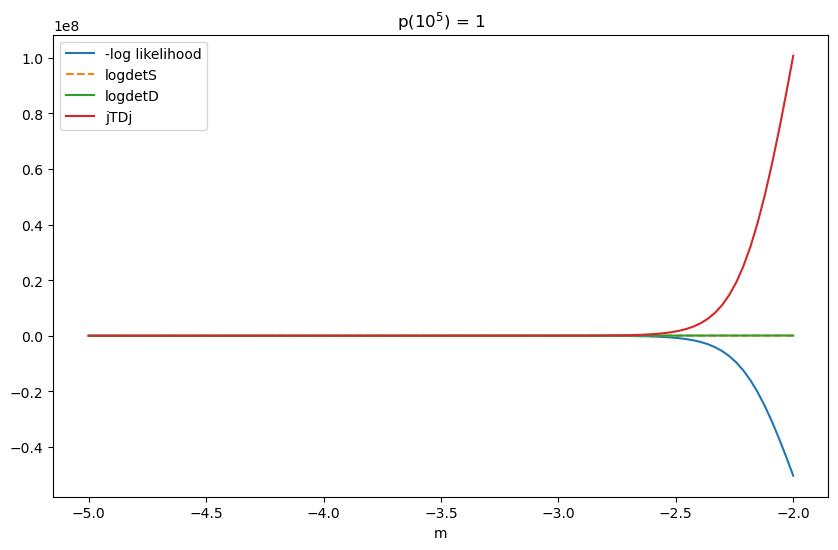

In [33]:
plt.figure(figsize=(10, 6))
plt.plot(ms, p_p1_minus_log_likelihood, label='-log likelihood')
#plt.plot(ms, p_p1_intensity, label = 'intensity')
plt.plot(ms, p_p1_logdetS, ls = '--', label='logdetS')
plt.plot(ms, p_p1_logdetD, label='logdetD')
plt.plot(ms, p_p1_jTDj, label='jTDj')
#plt.yscale('log')
plt.legend()
plt.xlabel('m')
plt.title(r'p($10^5$) = 1')